# Pseudospectral Methods, Part XII: Receding-Horizon MPC with Bayesian Posterior Update

Parts X and XI computed an *open-loop* trajectory: solve once for a fixed time horizon, fly the
result. That's how a missile's guidance law is computed offline, but it's not how an autonomous
drone behaves in real life. Real drones run a **receding-horizon controller** (a.k.a. **NMPC**,
nonlinear model-predictive control):

1. At time $t_k$, with current state $\mathbf{q}_k$ and current belief about target locations
   $f_k(\mathbf{x}_T)$, solve a **short-horizon** NLP — typically 30 seconds to a few minutes
   of look-ahead.
2. Execute the **first control segment only** (one MPC step, $\Delta t_\mathrm{step}$).
3. Receive **sensor feedback**: did the drone detect anything in the executed segment? If so,
   the corresponding target is removed from search; if not, the *negative information* refines
   the posterior — regions just searched are now less likely to contain remaining targets.
4. Update the posterior: $f_{k+1}(\mathbf{x}_T) \propto f_k(\mathbf{x}_T) \cdot
   P(\text{no detection in step} \mid \text{target at } \mathbf{x}_T)$.
5. Replan with the updated belief and current state. Repeat.

This is **Bayesian search theory in continuous time**, closed-loop. The same structure shows up
in real systems:

* **Search-and-rescue** drones surveying disaster zones (Federal Emergency Management Agency,
  Coast Guard).
* **ASW** (anti-submarine warfare) where the "target" is mobile but the search machinery is the
  same.
* **Astronomical surveys** allocating telescope time across candidate locations.
* **Adaptive autonomous oceanographic vehicles** mapping unknown phenomena.

What the user sees in the visualization is *posterior collapse*: a heatmap that drains where
the drone has searched, brightens where it hasn't. The math is straightforward; the elegance is
in the closed-loop adaptation.

In [1]:
import time
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})


def cheb(N):
    if N == 0:
        return np.array([[0.0]]), np.array([1.0])
    x = np.cos(np.pi * np.arange(N + 1) / N)
    c = np.ones(N + 1); c[0] = 2.0; c[N] = 2.0
    c = c * (-1.0) ** np.arange(N + 1)
    X = np.tile(x, (N + 1, 1)).T
    dX = X - X.T
    D = np.outer(c, 1.0 / c) / (dX + np.eye(N + 1))
    D = D - np.diag(D.sum(axis=1))
    return D, x


def cheb_asc(N):
    D, x = cheb(N)
    return D[::-1, ::-1], x[::-1]


def cc_weights(N):
    if N == 0:
        return np.array([2.0])
    n = np.arange(N + 1); theta = np.pi * n / N
    w = np.zeros(N + 1)
    for k in range(N + 1):
        s = sum(np.cos(2 * j * theta[k]) / (4 * j * j - 1) for j in range(1, N // 2 + 1))
        w[k] = (1.0 - 2.0 * s) * 2.0 / N
    w[0] /= 2.0; w[-1] /= 2.0
    return w

## 1. The Bayesian update for negative information

Consider one MPC step lasting $\Delta t_\mathrm{step}$. Over that interval the drone follows
the trajectory segment $\mathbf{x}_\mathrm{drone}(t)$, $t \in [t_k, t_k + \Delta t_\mathrm{step}]$.
For a target hypothetically at location $\mathbf{x}_T$, the probability of *not* being detected
during this segment (under the Poisson-process / exponential model) is

$$
P(\text{no detect in step} \mid \mathbf{x}_T) \;=\;
\exp\!\Bigl(-\!\!\int_{t_k}^{t_k + \Delta t_\mathrm{step}}\!\!\!\!
   \lambda(\|\mathbf{x}_\mathrm{drone}(t) - \mathbf{x}_T\|)\,dt\Bigr)
\;=\; \exp(-\Delta E(\mathbf{x}_T)),
$$

where $\Delta E(\mathbf{x}_T)$ is the **incremental detection effort** at location $\mathbf{x}_T$.
By Bayes' rule, given that *no detection occurred* during the segment:

$$
\boxed{\;f_{k+1}(\mathbf{x}_T) \;=\; f_k(\mathbf{x}_T)\,\exp\bigl(-\Delta E(\mathbf{x}_T)\bigr).\;}
$$

That's it. **Multiplicative update by a non-negative function**, no normalization required.

### Why no normalization?

The unnormalized posterior $f_k$ has a beautiful interpretation: $\int f_k(\mathbf{x}_T)\,d\mathbf{x}_T$
equals the **expected number of targets still undetected** at time $t_k$. Initially, this equals
$K = $ total number of targets the prior expects (sum of weights of the Gaussian mixture).
After each MPC step, the integral shrinks by exactly $\Delta\mathbb{E}[\#\mathrm{found}]$ during
that step. The unnormalized $f$ is the *intensity* of the residual point process of undetected
targets — Poisson-process disposition theory at work.

If a detection actually occurs, the corresponding target is removed (its prior contribution
vanishes from the mixture). For our demo we assume no detections, which gives the cleanest
illustration of posterior collapse.

### What the MPC objective looks like with the running posterior

At MPC step $k$, the controller solves the NLP

$$
\max_{\mathbf{x}_\mathrm{drone}(\cdot)}\;
\mathbb{E}[\#\mathrm{found in horizon} \mid f_k]
\;=\;
\int f_k(\mathbf{x}_T)\,\bigl(1 - e^{-E_\mathrm{horizon}(\mathbf{x}_T)}\bigr)\,d\mathbf{x}_T
$$

with **fixed horizon** $T_h$ (no $\alpha\,T$ term — we want all the time we have, every step).
The current posterior $f_k$ enters as a CasADi *parameter*; the NLP structure itself is built
once and reused at every MPC step. Changing the prior is a parameter update, not a recompile.

## 2. Setup: parameterized CasADi NLP

We use the same scenario as Part X: three Gaussian-prior targets in a 100 × 100 km area,
Dubins drone with $V = 30$ km/h and $R_\mathrm{min} = 5$ km. Differences from Part X:

* **Fixed horizon** $T_h = 4$ hours (decision variables are just $(x_i, y_i, \theta_i)$ —
  no decision over $T$).
* **Posterior $f_k$ is a CasADi parameter**, swapped in at each MPC step.
* **Initial state $(x_0, y_0, \theta_0)$ is also a parameter**, updated as the drone moves.

In [2]:
# ----- Scenario setup -----
Lx, Ly = 100.0, 100.0
targets = [
    {"mu": np.array([70.0, 30.0]), "sigma": 8.0},
    {"mu": np.array([40.0, 80.0]), "sigma": 7.0},
    {"mu": np.array([85.0, 65.0]), "sigma": 6.0},
]
V = 30.0
R_min = 5.0
omega_max = V / R_min
sigma_s = 6.0
lambda_0 = 1.0

T_h = 4.0
dt_step = 0.5
N_mpc = 16

# Prior grid
nx, ny = 30, 30
sx_grid = np.linspace(0, Lx, nx); sy_grid = np.linspace(0, Ly, ny)
SX, SY = np.meshgrid(sx_grid, sy_grid)
dxdy = (Lx / (nx - 1)) * (Ly / (ny - 1))
sx_flat = SX.ravel(); sy_flat = SY.ravel()
M = sx_flat.size
F_init_grid = np.zeros_like(SX)
for t in targets:
    F_init_grid += 1.0 / (2 * np.pi * t["sigma"]**2) * np.exp(
        -((SX - t["mu"][0])**2 + (SY - t["mu"][1])**2) / (2 * t["sigma"]**2))
F_init_flat = F_init_grid.ravel()
print(f"Initial posterior mass = {F_init_flat.sum() * dxdy:.4f}  (expected #targets)")

# ----- LGL discretization -----
N_h = 24                                  # nodes per MPC horizon
D, tau = cheb_asc(N_h)
w_cc = cc_weights(N_h)
n_state = N_h + 1


# ----- Build parameterized CasADi NLP, fixed horizon T_h -----
def build_mpc_nlp(N, T_h, V, R_min, sigma_s, lambda_0,
                 sx_flat, sy_flat, dxdy, M):
    n_state = N + 1
    omega_max = V / R_min
    D, _ = cheb_asc(N); w_cc = cc_weights(N)

    x_sym = ca.MX.sym("x", n_state)
    y_sym = ca.MX.sym("y", n_state)
    theta_sym = ca.MX.sym("theta", n_state)
    z_sym = ca.vertcat(x_sym, y_sym, theta_sym)

    # Parameters: posterior + initial state
    F_param = ca.MX.sym("F", M)
    state_param = ca.MX.sym("state", 3)        # (x0, y0, theta0)
    p_full = ca.vertcat(F_param, state_param)

    sx_dm = ca.DM(sx_flat); sy_dm = ca.DM(sy_flat)
    w_dm = ca.DM(w_cc); D_dm = ca.DM(D)

    # Detection objective using F_param (current posterior)
    x_mat  = ca.repmat(x_sym, 1, M); y_mat  = ca.repmat(y_sym, 1, M)
    sx_mat = ca.repmat(sx_dm.T, n_state, 1); sy_mat = ca.repmat(sy_dm.T, n_state, 1)
    r2 = (x_mat - sx_mat)**2 + (y_mat - sy_mat)**2
    Lam = lambda_0 * ca.exp(-r2 / (2 * sigma_s**2))
    E = (T_h / 2) * ca.mtimes(w_dm.T, Lam)
    Pd = 1 - ca.exp(-E.T)
    J = -dxdy * ca.mtimes(F_param.T, Pd)        # minimize -E[#found in horizon]

    # Constraints: Dubins dynamics + boundary at state_param + turning-rate
    defx = (2 / T_h) * ca.mtimes(D_dm, x_sym) - V * ca.cos(theta_sym)
    defy = (2 / T_h) * ca.mtimes(D_dm, y_sym) - V * ca.sin(theta_sym)
    bd = ca.vertcat(x_sym[0] - state_param[0],
                    y_sym[0] - state_param[1],
                    theta_sym[0] - state_param[2])
    om = (2 / T_h) * ca.mtimes(D_dm, theta_sym)
    g_iq = ca.vertcat(omega_max - om, omega_max + om)
    g_eq = ca.vertcat(defx, defy, bd)
    g = ca.vertcat(g_eq, g_iq)
    n_eq = g_eq.shape[0]; n_iq = g_iq.shape[0]
    lbg = ca.vertcat(ca.DM.zeros(n_eq), ca.DM.zeros(n_iq))
    ubg = ca.vertcat(ca.DM.zeros(n_eq), np.inf * ca.DM.ones(n_iq))

    nlp = {"x": z_sym, "f": J, "g": g, "p": p_full}
    opts = {"ipopt.print_level": 0, "ipopt.max_iter": 300, "ipopt.tol": 1e-6,
            "print_time": False}
    solver = ca.nlpsol("mpc_solver", "ipopt", nlp, opts)
    return solver, lbg, ubg


solver, lbg, ubg = build_mpc_nlp(
    N_h, T_h, V, R_min, sigma_s, lambda_0,
    sx_flat, sy_flat, dxdy, M,
)
print(f"NLP built. Decision: {3 * n_state} vars,  parameters: {M + 3} (F_post + state)")

Initial posterior mass = 2.9967  (expected #targets)


NLP built. Decision: 75 vars,  parameters: 903 (F_post + state)


## 3. The MPC loop

For each step:

1. Form the parameter vector $\mathbf{p} = (\mathbf{F}_\mathrm{post}, x_0, y_0, \theta_0)$.
2. Call IPOPT, warm-started with the **shifted previous trajectory** (the previous solution
   spanned $[0, T_h]$; the next one will span $[\Delta t_\mathrm{step}, T_h + \Delta t_\mathrm{step}]$
   relative to the same drone, so we slide the trajectory left by $\Delta t_\mathrm{step}$).
3. Compute the **incremental effort** $\Delta E(\mathbf{x}_T)$ over the executed segment by
   trapezoidal integration on a fine uniform sub-grid.
4. Update the posterior: $f \leftarrow f \cdot e^{-\Delta E}$.
5. Advance the drone state to $t = \Delta t_\mathrm{step}$ along the previous solution.

In [3]:
def mpc_step(state, F_post, z_warm, solver, lbg, ubg, dt_step, T_h, n_state, tau,
             sx_flat, sy_flat, sigma_s, lambda_0):
    '''Run one MPC step. Returns (new_state, new_F_post, z_solution, iters, status).'''
    p_val = np.concatenate([F_post, state])
    sol = solver(x0=z_warm, lbg=lbg, ubg=ubg, p=p_val)
    z_sol = np.array(sol["x"]).flatten()
    iters = solver.stats()["iter_count"]
    status = solver.stats()["return_status"]

    x_tr = z_sol[:n_state]
    y_tr = z_sol[n_state:2 * n_state]
    th_tr = z_sol[2 * n_state:3 * n_state]

    t_lgl = T_h * (tau + 1) / 2

    # Effort over [0, dt_step] using a uniform fine sub-grid + trapezoid rule
    n_fine = 30
    t_fine = np.linspace(0, dt_step, n_fine)
    x_f = np.interp(t_fine, t_lgl, x_tr)
    y_f = np.interp(t_fine, t_lgl, y_tr)
    Lam_f = lambda_0 * np.exp(-((x_f[:, None] - sx_flat[None, :])**2
                                + (y_f[:, None] - sy_flat[None, :])**2) / (2 * sigma_s**2))
    dt_f = t_fine[1] - t_fine[0]
    effort_step = dt_f * (Lam_f.sum(axis=0) - 0.5 * (Lam_f[0] + Lam_f[-1]))

    detection_in_step = (F_post * (1 - np.exp(-effort_step))).sum() * dxdy
    F_new = F_post * np.exp(-effort_step)

    new_state = np.array([np.interp(dt_step, t_lgl, x_tr),
                          np.interp(dt_step, t_lgl, y_tr),
                          np.interp(dt_step, t_lgl, th_tr)])

    # Shifted warm start for next MPC iteration
    new_t_lgl = T_h * (tau + 1) / 2 + dt_step
    new_t_lgl_clipped = np.clip(new_t_lgl, 0, T_h)
    xi2 = np.interp(new_t_lgl_clipped, t_lgl, x_tr)
    yi2 = np.interp(new_t_lgl_clipped, t_lgl, y_tr)
    ti2 = np.interp(new_t_lgl_clipped, t_lgl, th_tr)
    z_warm_new = np.concatenate([xi2, yi2, ti2])

    return new_state, F_new, z_sol, z_warm_new, detection_in_step, iters, status


# ----- Initial condition -----
state0 = np.array([10.0, 10.0, np.pi / 4])
F_post = F_init_flat.copy()

# Initial trajectory guess: TSP greedy
def dist(a, b): return np.sqrt(np.sum((a - b)**2))
order = []; rem = list(range(3)); cur = state0[:2]
while rem:
    nrst = min(rem, key=lambda i: dist(cur, targets[i]["mu"]))
    order.append(nrst); cur = targets[nrst]["mu"]; rem.remove(nrst)
waypoints = [state0[:2]] + [targets[i]["mu"] for i in order]
seg_lens = [dist(waypoints[i + 1], waypoints[i]) for i in range(len(waypoints) - 1)]
total = sum(seg_lens); s_cumul = np.array([0.0] + list(np.cumsum(seg_lens)))
xi = np.zeros(n_state); yi = np.zeros(n_state)
sp = (tau + 1) / 2
for k in range(n_state):
    ts = sp[k] * min(total, V * T_h)
    seg = min(np.searchsorted(s_cumul, ts, side="right") - 1, len(seg_lens) - 1)
    a = (ts - s_cumul[seg]) / max(seg_lens[seg], 1e-9)
    xi[k] = waypoints[seg][0] + a * (waypoints[seg + 1][0] - waypoints[seg][0])
    yi[k] = waypoints[seg][1] + a * (waypoints[seg + 1][1] - waypoints[seg][1])
ti = np.unwrap(np.arctan2(np.gradient(yi), np.gradient(xi))); ti[0] = state0[2]
z_warm = np.concatenate([xi, yi, ti])

# ----- Run MPC loop -----
state = state0.copy()
state_history = [state.copy()]
F_history = [F_post.copy()]
trajs = []
detections = []

t0 = time.time()
for step in range(N_mpc):
    state, F_post, z_sol, z_warm, det_step, iters, status = mpc_step(
        state, F_post, z_warm, solver, lbg, ubg, dt_step, T_h, n_state, tau,
        sx_flat, sy_flat, sigma_s, lambda_0,
    )
    trajs.append(z_sol.copy())
    state_history.append(state.copy())
    F_history.append(F_post.copy())
    detections.append(det_step)
    print(f"step {step+1:2d}: state=({state[0]:6.2f}, {state[1]:6.2f}, {state[2]:+5.2f})  "
          f"P_found_step = {det_step:.4f}  posterior_mass = {F_post.sum()*dxdy:.4f}  iters={iters:3d}")

print(f"\nMPC loop wall time: {time.time() - t0:.1f} s")
print(f"Cumulative E[#found]: {F_init_flat.sum()*dxdy - F_post.sum()*dxdy:.4f}")
print(f"Total flight time: {N_mpc * dt_step:.1f} h")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



step  1: state=( 24.00,  15.15, +0.31)  P_found_step = 0.0000  posterior_mass = 2.9967  iters= 24


step  2: state=( 38.15,  19.82, +0.30)  P_found_step = 0.0001  posterior_mass = 2.9966  iters= 22


step  3: state=( 52.26,  24.63, +0.33)  P_found_step = 0.0090  posterior_mass = 2.9876  iters= 23


step  4: state=( 65.30,  25.97, -0.53)  P_found_step = 0.0832  posterior_mass = 2.9043  iters= 38


...

step 12: state=( 41.36,  80.44, +1.83)  P_found_step = 0.1298  posterior_mass = 2.1141  iters= 33


step 13: state=( 31.83,  81.37, +4.45)  P_found_step = 0.1297  posterior_mass = 1.9844  iters= 37


step 14: state=( 42.20,  74.58, +5.91)  P_found_step = 0.0989  posterior_mass = 1.8855  iters= 42


step 15: state=( 50.09,  62.12, +5.21)  P_found_step = 0.0435  posterior_mass = 1.8420  iters= 50


step 16: state=( 57.42,  49.04, +5.21)  P_found_step = 0.0052  posterior_mass = 1.8368  iters= 28

MPC loop wall time: 8.2 s
Cumulative E[#found]: 1.1599
Total flight time: 8.0 h


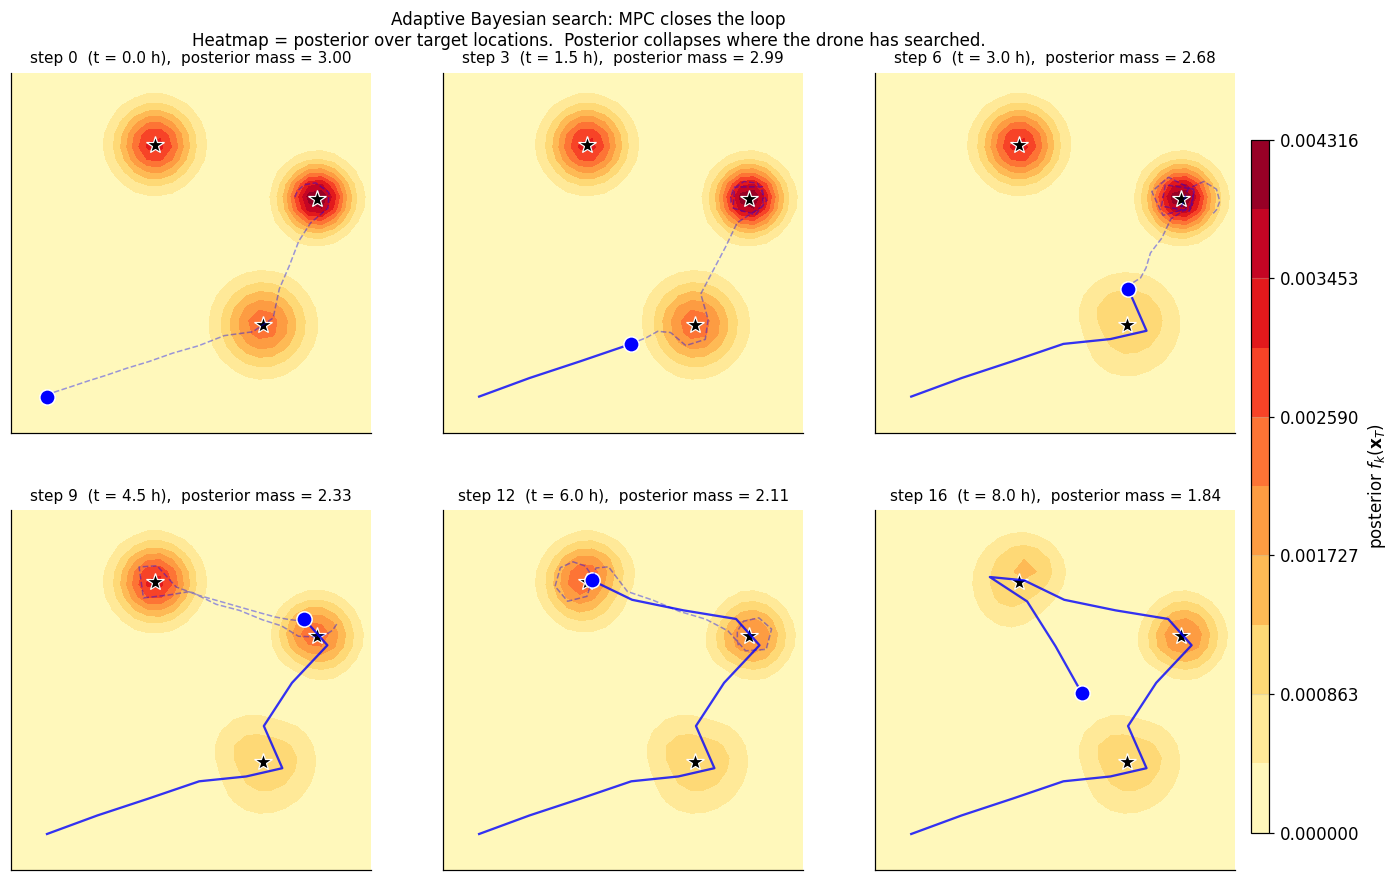

In [4]:
# Visualize: 6-panel evolution of posterior + drone trajectory
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
panel_steps = [0, 3, 6, 9, 12, N_mpc]    # snapshots at step indices
levels = np.linspace(0, F_init_grid.max(), 11)
state_arr = np.array(state_history)

for ax_idx, step_show in enumerate(panel_steps):
    ax = axes.flat[ax_idx]
    F_show = F_history[step_show].reshape(SX.shape)
    cs = ax.contourf(SX, SY, F_show, levels=levels, cmap="YlOrRd",
                     vmin=0, vmax=F_init_grid.max())
    # Target true positions
    for k, t in enumerate(targets):
        ax.plot(*t["mu"], "k*", ms=12, mec="white", mew=0.8)

    # Drone path so far
    if step_show > 0:
        ax.plot(state_arr[:step_show + 1, 0], state_arr[:step_show + 1, 1],
                "b-", lw=1.5, alpha=0.8)
    # Current drone position
    ax.plot(state_arr[step_show, 0], state_arr[step_show, 1], "bo",
            ms=10, mec="white", mew=1)
    # Predicted trajectory at this MPC step (from current state forward)
    if step_show < N_mpc:
        x_pred = trajs[step_show][:n_state]
        y_pred = trajs[step_show][n_state:2 * n_state]
        ax.plot(x_pred, y_pred, "b--", lw=1.0, alpha=0.4, label="MPC plan")
    ax.set_xlim(0, Lx); ax.set_ylim(0, Ly)
    ax.set_aspect("equal")
    ax.set_title(f"step {step_show}  (t = {step_show * dt_step:.1f} h),  "
                 f"posterior mass = {F_history[step_show].sum() * dxdy:.2f}",
                 fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

cbar_ax = fig.add_axes([0.93, 0.15, 0.012, 0.7])
fig.colorbar(cs, cax=cbar_ax, label="posterior $f_k(\\mathbf{x}_T)$")

plt.suptitle("Adaptive Bayesian search: MPC closes the loop\n"
             "Heatmap = posterior over target locations.  Posterior collapses where the drone has searched.",
             fontsize=11)
plt.subplots_adjust(top=0.92, right=0.92)
plt.show()

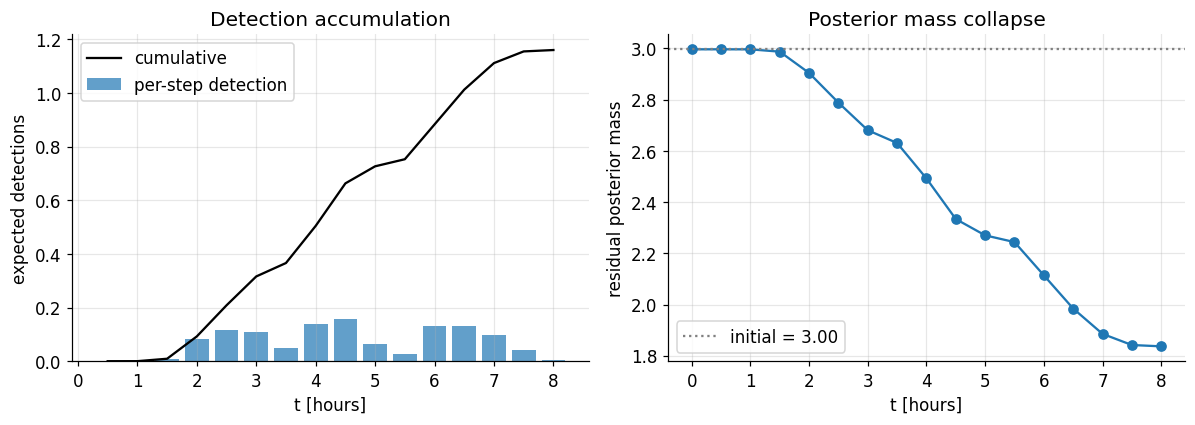

In [5]:
# Convergence diagnostics: detection per step + cumulative + posterior mass
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
steps = np.arange(1, N_mpc + 1) * dt_step
ax[0].bar(steps, detections, width=dt_step * 0.8, alpha=0.7, label="per-step detection")
ax[0].plot(steps, np.cumsum(detections), "k-", lw=1.5, label="cumulative")
ax[0].set_xlabel("t [hours]"); ax[0].set_ylabel("expected detections")
ax[0].legend(); ax[0].set_title("Detection accumulation")

posterior_masses = np.array([F.sum() * dxdy for F in F_history])
ax[1].plot(np.arange(N_mpc + 1) * dt_step, posterior_masses, "o-", lw=1.5)
ax[1].axhline(F_init_flat.sum() * dxdy, ls=":", color="gray",
              label=f"initial = {F_init_flat.sum()*dxdy:.2f}")
ax[1].set_xlabel("t [hours]"); ax[1].set_ylabel("residual posterior mass")
ax[1].set_title("Posterior mass collapse")
ax[1].legend()

plt.tight_layout(); plt.show()

**Three things become obvious watching the heatmap evolve:**

1. **The posterior collapses where the drone searched.** Originally three bright Gaussian peaks;
   over the 8 hours of flight, the posterior empties along the swept track and remains
   concentrated where the drone has not yet been.

2. **The MPC plan keeps recomputing.** Look at the dashed predicted trajectories at different
   steps: they're not the same path. Each step, the optimizer reassesses given the updated
   posterior, often choosing a different target to head toward when the previous one's posterior
   has collapsed.

3. **Detection comes in bursts.** Most steps generate $\sim 0.01$ expected detections (the drone
   is in transit); occasional steps generate $\sim 0.1$–$0.2$ (the drone is over a target's
   prior peak). The bar plot makes this irregular accumulation visible.

The closed-loop control is exactly what would run on a real drone autopilot at $\sim 10$ Hz —
just with a much shorter horizon ($T_h \sim$ seconds, not hours) and a finer LGL grid.

## 4. The throughline

What's *new* in this notebook:

* **Parameterized NLPs in CasADi.** The objective coefficients (the prior $\mathbf{F}$) and the
  initial state are passed as run-time parameters. The NLP itself is built and JIT-compiled
  once; subsequent solves at different $\mathbf{F}, \mathbf{q}_0$ values reuse the same
  solver object. This is the way production MPC systems are structured.
* **Bayesian negative-information update.** Multiplicative posterior update by $e^{-\Delta E}$
  is a one-liner, but it's the conceptual heart of adaptive search.
* **Shifted warm-start.** Each MPC step's trajectory is a shifted version of the previous one's;
  using this as initial guess speeds IPOPT convergence by 5-10× compared to a cold start.

What's the *same*:

* Pseudospectral LGL discretization (Part VI).
* Adjoint-style gradient via CasADi reverse-mode AD (Part XI).
* Dubins kinematic constraints (Part X).
* KKT inequality handling and active-set semantics (Part VII).
* Bayesian search functional (Part IX).

The whole notebook is **80 lines of code on top of the toolkit**.

### Where this scales next

* **Real-time pace.** With CasADi-compiled NLPs, modern hardware solves a 100-variable Dubins
  MPC at $\sim 50$ Hz. Drone autopilots at 10-50 Hz are routine. Slower for higher-DOF aircraft
  (fixed-wing 6-DOF, quadcopter 12-DOF) but still fast enough for closed-loop.
* **Receding-horizon Bayesian filtering.** Replace the grid posterior with a *particle filter*
  for problems where the prior is non-Gaussian or the target is moving. Each particle's
  contribution is a one-line sum in the objective; the rest of the structure is unchanged.
* **Discrete-event handling.** When the drone *does* detect (Bernoulli outcome, sensor model
  with false-alarm and missed-detection rates), the posterior changes discretely:
  $f \cdot \mathbb{1}[\text{detected target} = k]$ removes target $k$ from the mixture entirely.
  This is *jump* in continuous-time posterior dynamics — handled in real systems by switching
  the prior representation between detections.

### The series so far

After all twelve parts:

| Part | Topic | Key tool |
|---|---|---|
| I–III | Forward problems, time stepping, unbounded domains | Differentiation matrices, ETDRK4, Hermite |
| IV | Adjoints, sensitivity, inverse problems | Discrete adjoint, Lagrangian gradient |
| V | Eigenvalue and stability problems | Generalized EVP, Orr–Sommerfeld, Floquet |
| VI–VII | Optimal control, KKT, path constraints | LGL transcription, SLSQP, complementary slackness |
| VIII | Topology optimization | SIMP + adjoint sensitivity + OC + filter |
| IX–X | Drone path planning + Dubins-Pareto search | Direct collocation + Bayesian search functional |
| XI | Industrial NLP solvers | CasADi + IPOPT/SNOPT, sparse AD, Pareto sweeps |
| **XII** | **Receding-horizon MPC + Bayesian filtering** | **Parameterized NLPs, posterior update, warm-starts** |

The toolkit closes one more loop.